In [31]:
# stb_image.h allows reading png and jpg images
# stb_image_write.h allows saving the output image after the K-Means segmentation/clustering into an image with format like jpg or png

!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

--2026-05-05 12:07:44--  https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 283010 (276K) [text/plain]
Saving to: ‘stb_image.h.1’

stb_image.h.1       100%[===================>] 276.38K  --.-KB/s    in 0.004s  

2026-05-05 12:07:44 (73.7 MB/s) - ‘stb_image.h.1’ saved [283010/283010]

--2026-05-05 12:07:44--  https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71221 (70K) [text/plain]
Saving to: ‘stb_im

In [32]:
# %%writefile pure_kmeans.cpp
# #define STB_IMAGE_IMPLEMENTATION
# #include "stb_image.h"
# #define STB_IMAGE_WRITE_IMPLEMENTATION
# #include "stb_image_write.h"

# #include <iostream>
# #include <vector>
# #include <cstdlib>
# #include <ctime>
# #include <cmath>

# using namespace std;

# struct Centroid {
#     double r, g, b;
# };

# // Calculate distance between a pixel pointer and a centroid
# double getDistance(unsigned char* pixel, Centroid c) {
#     return sqrt(pow(pixel[0] - c.r, 2) + pow(pixel[1] - c.g, 2) + pow(pixel[2] - c.b, 2));
# }

# int main(int argc, char** argv) {
#     if (argc < 3) {
#         cout << "Usage: ./pure_kmeans <image_path> <K>" << endl;
#         return -1;
#     }

#     const char* img_path = argv[1];
#     int K = atoi(argv[2]);
#     int max_iters = 100;

#     int width, height, channels;
#     // Load image, forcing 3 channels (RGB)
#     unsigned char *img_data = stbi_load(img_path, &width, &height, &channels, 3);
#     if (!img_data) {
#         cout << "Error: Could not read the image." << endl;
#         return -1;
#     }

#     int total_pixels = width * height;

#     // 1. Initialize K centroids randomly from actual image pixels
#     srand(time(0));
#     vector<Centroid> centroids(K);
#     for (int i = 0; i < K; i++) {
#         int random_idx = (rand() % total_pixels) * 3;
#         centroids[i].r = img_data[random_idx];
#         centroids[i].g = img_data[random_idx + 1];
#         centroids[i].b = img_data[random_idx + 2];
#     }

#     vector<int> labels(total_pixels, 0);
#     bool changed = true;
#     int iter = 0;

#     cout << "Starting pure sequential K-Means clustering..." << endl;

#     // 2. Sequential Training Loop
#     while (changed && iter < max_iters) {
#         changed = false;
#         vector<double> sum_r(K, 0), sum_g(K, 0), sum_b(K, 0);
#         vector<int> counts(K, 0);

#         for (int p = 0; p < total_pixels; p++) {
#             unsigned char* pixel = &img_data[p * 3];
#             double min_dist = 1e9;
#             int best_cluster = 0;

#             for (int c = 0; c < K; c++) {
#                 double dist = getDistance(pixel, centroids[c]);
#                 if (dist < min_dist) {
#                     min_dist = dist;
#                     best_cluster = c;
#                 }
#             }

#             if (labels[p] != best_cluster) {
#                 changed = true;
#                 labels[p] = best_cluster;
#             }

#             sum_r[best_cluster] += pixel[0];
#             sum_g[best_cluster] += pixel[1];
#             sum_b[best_cluster] += pixel[2];
#             counts[best_cluster]++;
#         }

#         // Update centroids
#         for (int c = 0; c < K; c++) {
#             if (counts[c] > 0) {
#                 centroids[c].r = sum_r[c] / counts[c];
#                 centroids[c].g = sum_g[c] / counts[c];
#                 centroids[c].b = sum_b[c] / counts[c];
#             }
#         }
#         iter++;
#     }

#     // 3. Create segmented output array
#     unsigned char* out_data = new unsigned char[total_pixels * 3];
#     for (int p = 0; p < total_pixels; p++) {
#         int cluster_idx = labels[p];
#         out_data[p * 3]     = static_cast<unsigned char>(centroids[cluster_idx].r);
#         out_data[p * 3 + 1] = static_cast<unsigned char>(centroids[cluster_idx].g);
#         out_data[p * 3 + 2] = static_cast<unsigned char>(centroids[cluster_idx].b);
#     }

#     // Write output to JPEG
#     stbi_write_jpg("pure_segmented_output.jpg", width, height, 3, out_data, 100);

#     cout << "Segmentation complete in " << iter << " iterations." << endl;

#     // Free memory
#     stbi_image_free(img_data);
#     delete[] out_data;

#     return 0;
# }

Overwriting pure_kmeans.cpp


In [36]:
%%writefile pure_kmeans.cpp
#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

#include <iostream>
#include <vector>
#include <cstdlib>
#include <ctime>
// <cmath> removed: We no longer need pow() or sqrt(), improving speed.

using namespace std;

// Structure to store the RGB color of our cluster centers
struct Centroid {
    double r, g, b;
};

// OPTIMIZATION 1: Use Squared Distance
// Executing sqrt() and pow() millions of times inside a nested loop is a massive bottleneck.
// Since we only need to compare distances to find the smallest one, comparing squared distances yields the exact same result but executes significantly faster.
double getSquaredDistance(unsigned char* pixel, Centroid c) {
    double dr = pixel[0] - c.r;
    double dg = pixel[1] - c.g;
    double db = pixel[2] - c.b;
    return (dr * dr) + (dg * dg) + (db * db);
}

int main(int argc, char** argv) {
    // 1. INPUT VALIDATION
    if (argc < 3) {
        cout << "Usage: ./pure_kmeans <image_path> <K>" << endl;
        return -1;
    }

    const char* img_path = argv[1];
    int K = atoi(argv[2]);
    int max_iters = 100;

    // 2. LOAD IMAGE
    int width, height, channels;
    // stbi_load returns a 1D array of bytes. We force 3 channels (RGB).
    unsigned char *img_data = stbi_load(img_path, &width, &height, &channels, 3);
    if (!img_data) {
        cout << "Error: Could not read the image." << endl;
        return -1;
    }

    int total_pixels = width * height;

    // 3. INITIALIZATION
    srand(time(0));
    vector<Centroid> centroids(K);
    vector<int> labels(total_pixels, 0);

    // Pick K random pixels from the image to act as starting centroids
    for (int i = 0; i < K; i++) {
        int random_idx = (rand() % total_pixels) * 3;
        centroids[i].r = img_data[random_idx];
        centroids[i].g = img_data[random_idx + 1];
        centroids[i].b = img_data[random_idx + 2];
    }

    // OPTIMIZATION 2: Pre-allocate Memory
    // Instead of declaring these vectors inside the while loop (which forces the CPU to allocate and deallocate memory every iteration), we declare them once here.
    vector<double> sum_r(K), sum_g(K), sum_b(K);
    vector<int> counts(K);

    bool changed = true;
    int iter = 0;

    cout << "Starting optimized sequential K-Means clustering..." << endl;

    // 4. MAIN ALGORITHM LOOP
    while (changed && iter < max_iters) {
        changed = false;

        // Reset the accumulators to zero for the new iteration
        fill(sum_r.begin(), sum_r.end(), 0.0);
        fill(sum_g.begin(), sum_g.end(), 0.0);
        fill(sum_b.begin(), sum_b.end(), 0.0);
        fill(counts.begin(), counts.end(), 0);

        // Step A: Assign every pixel to the nearest centroid
        for (int p = 0; p < total_pixels; p++) {
            unsigned char* pixel = &img_data[p * 3];

            double min_dist = 1e18; // Start with an arbitrarily large number
            int best_cluster = 0;

            for (int c = 0; c < K; c++) {
                double dist = getSquaredDistance(pixel, centroids[c]);
                if (dist < min_dist) {
                    min_dist = dist;
                    best_cluster = c;
                }
            }

            // If the pixel changed clusters, flag that we need another iteration
            if (labels[p] != best_cluster) {
                changed = true;
                labels[p] = best_cluster;
            }

            // Add pixel colors to the newly assigned cluster's running total
            sum_r[best_cluster] += pixel[0];
            sum_g[best_cluster] += pixel[1];
            sum_b[best_cluster] += pixel[2];
            counts[best_cluster]++;
        }

        // Step B: Calculate the new centroids (averages)
        for (int c = 0; c < K; c++) {
            if (counts[c] > 0) { // Prevent division by zero
                centroids[c].r = sum_r[c] / counts[c];
                centroids[c].g = sum_g[c] / counts[c];
                centroids[c].b = sum_b[c] / counts[c];
            }
        }
        iter++;
    }

    // 5. RECONSTRUCT IMAGE
    // Allocate a new array for the final segmented image
    unsigned char* out_data = new unsigned char[total_pixels * 3];

    for (int p = 0; p < total_pixels; p++) {
        int cluster_idx = labels[p];
        out_data[p * 3]     = static_cast<unsigned char>(centroids[cluster_idx].r);
        out_data[p * 3 + 1] = static_cast<unsigned char>(centroids[cluster_idx].g);
        out_data[p * 3 + 2] = static_cast<unsigned char>(centroids[cluster_idx].b);
    }

    // Write the result to a JPEG file
    stbi_write_jpg("pure_segmented_output.jpg", width, height, 3, out_data, 100);

    cout << "Segmentation complete in " << iter << " iterations." << endl;

    // 6. CLEANUP MEMORY
    stbi_image_free(img_data);
    delete[] out_data;

    return 0;
}

Overwriting pure_kmeans.cpp


In [40]:
# Ensure the code is compiled first (if you haven't already in this session)
!g++ pure_kmeans.cpp -o pure_kmeans_exec -lm

# Run the executable with your Google Drive path
!./pure_kmeans_exec "/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png" 3

Starting optimized sequential K-Means clustering...
Segmentation complete in 14 iterations.


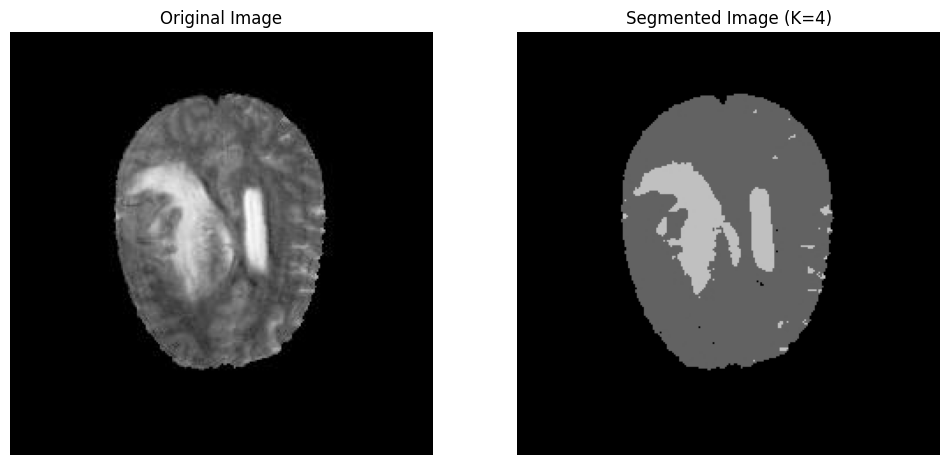

In [41]:
import matplotlib.pyplot as plt
import cv2
import os

input_path = "/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png"
output_path = "pure_segmented_output.jpg"

if os.path.exists(output_path):
    # Read images
    original = cv2.imread(input_path)
    segmented = cv2.imread(output_path)

    # Convert BGR to RGB for correct color display in Matplotlib
    if original is not None:
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    if segmented is not None:
        segmented = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)

    # Plot side by side
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    if original is not None:
        ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    if segmented is not None:
        ax[1].imshow(segmented)
    ax[1].set_title("Segmented Image (K=4)")
    ax[1].axis("off")

    plt.show()
else:
    print("Error: Output image not found. The C++ code might have failed to run.")